## Imports

In [2]:
import re
from collections import Counter

import os

sys.path.append(os.path.abspath("../numpy"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import Data
from layers import DenseLayer
from activation import ReLUActivation, SoftmaxActivation
from neuralnet import NeuralNetwork
from losses import CategoricalCrossEntropy
from metrics import accuracy

## Ler os datasets

In [3]:
train_df = pd.read_csv("../dataset_train.csv", sep=";")
test_df = pd.read_csv("../subm3.csv", sep=";")


print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (47595, 3)
Test shape: (150, 2)


,Original_ID,Text,Label
0,WIKI-10197,These accounts contributed to Darwin's theory ...,Human
1,WIKI-4711,"(August 1, 1997), Applied Numerical Linear Alg...",Anthropic
2,WIKI-3421,Photogrammetry and digital topographical model...,Google
3,WIKI-4428,Every projective algebraic set may be uniquely...,Human
4,WIKI-7190,Optical illusions (also called visual illusion...,Google


,ID,Text
0,D2-126,The reality about the places that diamonds are...
1,D2-127,Geothermobarometric calculations for a worldwi...
2,D2-128,Diamonds are formed deep within the Earth’s ma...
3,D2-129,Diamond is a solid form of the element carbon ...
4,D2-130,Diamonds are formed deep within the Earth unde...


## Limpeza de texto

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def add_bigrams(text):
    words = text.split()
    bigrams = [words[i] + "_" + words[i+1] for i in range(len(words)-1)]
    return " ".join(words + bigrams)


cleanText=False ####################################### mudar 

if cleanText:
    train_df["clean_text"] = train_df["Text"].apply(clean_text)
    test_df["clean_text"] = test_df["Text"].apply(clean_text)
    print("com texto limpo")
else:
    train_df["clean_text"] = train_df["Text"]
    test_df["clean_text"] = test_df["Text"]
    print("sem texto limpo")

display(train_df[["Text", "clean_text", "Label"]].head())

sem texto limpo


,Text,clean_text,Label
0,These accounts contributed to Darwin's theory ...,These accounts contributed to Darwin's theory ...,Human
1,"(August 1, 1997), Applied Numerical Linear Alg...","(August 1, 1997), Applied Numerical Linear Alg...",Anthropic
2,Photogrammetry and digital topographical model...,Photogrammetry and digital topographical model...,Google
3,Every projective algebraic set may be uniquely...,Every projective algebraic set may be uniquely...,Human
4,Optical illusions (also called visual illusion...,Optical illusions (also called visual illusion...,Google


## Ver classes

In [5]:
print("Classes:")
print(train_df["Label"].value_counts())

Classes:
Label
Human        10448
Google       10448
OpenAI       10106
Meta          9993
Anthropic     6600
Name: count, dtype: int64


## Construir vocabulário

Bag of Words

In [6]:
def build_vocab(texts, max_features=20000, min_freq=2):
    counter = Counter()
    
    for text in texts:
        counter.update(text.split())
    
    vocab_items = [
        word for word, freq in counter.items()
        if freq >= min_freq
    ]
    
    vocab_items = sorted(
        vocab_items,
        key=lambda word: counter[word],
        reverse=True
    )[:max_features]
    
    vocab = {word: idx for idx, word in enumerate(vocab_items)}
    return vocab



## Transformar texto em Bag of Words

In [7]:
def text_to_bow(texts, vocab):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float32)
    
    for i, text in enumerate(texts):
        for word in text.split():
            if word in vocab:
                X[i, vocab[word]] += 1.0
                
    return X


## Transformar texto em TFIDF

In [8]:
def compute_idf(texts, vocab):
    n_docs = len(texts)
    df = np.zeros(len(vocab), dtype=np.float32)

    for text in texts:
        seen_words = set()
        for word in text.split():
            if word in vocab and word not in seen_words:
                df[vocab[word]] += 1
                seen_words.add(word)

    idf = np.log((n_docs + 1) / (df + 1)) + 1
    return idf

def text_to_tfidf(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float32)

    for i, text in enumerate(texts):
        words = text.split()
        if len(words) == 0:
            continue

        for word in words:
            if word in vocab:
                X[i, vocab[word]] += 1.0

        X[i] = X[i] / len(words)
        X[i] = X[i] * idf

        norm = np.linalg.norm(X[i])
        if norm > 0:
            X[i] = X[i] / norm


    return X


## Codificar labels

In [9]:
def fit_label_encoder(labels):
    classes = sorted(labels.unique())
    label_to_idx = {label: i for i, label in enumerate(classes)}
    idx_to_label = {i: label for label, i in label_to_idx.items()}
    return label_to_idx, idx_to_label

def encode_labels(labels, label_to_idx):
    return np.array([label_to_idx[label] for label in labels], dtype=np.int32)

def one_hot_encode(y, num_classes):
    y_onehot = np.zeros((len(y), num_classes), dtype=np.float32)
    y_onehot[np.arange(len(y)), y] = 1.0
    return y_onehot


## Split treino / validação

In [10]:
def train_val_split(X, y, val_size=0.2, seed=42):
    np.random.seed(seed)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    split_idx = int(len(X) * (1 - val_size))
    train_idx = indices[:split_idx]
    val_idx = indices[split_idx:]
    
    return X[train_idx], X[val_idx], y[train_idx], y[val_idx]

texts = train_df["clean_text"].to_numpy()
labels = train_df["Label"].to_numpy()

X_train_text, X_val_text, y_train_text, y_val_text = train_val_split(texts, labels, val_size=0.2, seed=42)

print("X_train:", X_train_text.shape)
print("X_val:", X_val_text.shape)
print("y_train:", y_train_text.shape)
print("y_val:", y_val_text.shape)

X_train: (38076,)
X_val: (9519,)
y_train: (38076,)
y_val: (9519,)


In [11]:
def fit_vectorizer(texts_train, use_tfidf=True, use_bigrams=False, max_features=15000, min_freq=2):
    if use_bigrams:
        texts_train = np.array([add_bigrams(t) for t in texts_train])

    vocab = build_vocab(texts_train, max_features=max_features, min_freq=min_freq)

    vectorizer = {
        "use_tfidf": use_tfidf,
        "use_bigrams": use_bigrams,
        "vocab": vocab,
        "idf": None
    }

    if use_tfidf:
        vectorizer["idf"] = compute_idf(texts_train, vocab)

    return vectorizer

In [12]:
def transform_texts(texts, vectorizer):
    if vectorizer["use_bigrams"]:
        texts = np.array([add_bigrams(t) for t in texts])

    vocab = vectorizer["vocab"]

    if vectorizer["use_tfidf"]:
        idf = vectorizer["idf"]
        return text_to_tfidf(texts, vocab, idf)
    else:
        return text_to_bow(texts, vocab)

In [13]:
def run_experiment(
    model_name,
    texts_train,
    texts_val,
    y_train,
    y_val,
    use_tfidf=True,
    use_bigrams=False,
    max_features=15000,
    min_freq=2,
    epochs=50,
    batch_size=32,
    learning_rate=None,
    momentum=0.9
):
    vectorizer = fit_vectorizer(
        texts_train,
        use_tfidf=use_tfidf,
        use_bigrams=use_bigrams,
        max_features=max_features,
        min_freq=min_freq
    )

    X_train = transform_texts(texts_train, vectorizer)
    X_val = transform_texts(texts_val, vectorizer)

    train_data = Data(X_train, y_train)
    val_data = Data(X_val, y_val)

    if model_name == "logreg":
        if learning_rate is None:
            learning_rate = 0.05

        model = NeuralNetwork(
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            momentum=momentum,
            verbose=True,
            loss=CategoricalCrossEntropy,
            metric=accuracy
        )
        model.add(DenseLayer(y_train.shape[1], input_shape=(X_train.shape[1],), l2_lambda=1e-4))
        model.add(SoftmaxActivation())

    elif model_name == "dnn":
        if learning_rate is None:
            learning_rate = 0.05

        model = NeuralNetwork(
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            momentum=momentum,
            verbose=True,
            loss=CategoricalCrossEntropy,
            metric=accuracy
        )
        model.add(DenseLayer(128, input_shape=(X_train.shape[1],), l2_lambda=1e-4))
        model.add(ReLUActivation())
        model.add(DenseLayer(64, l2_lambda=1e-4))
        model.add(ReLUActivation())
        model.add(DenseLayer(y_train.shape[1], l2_lambda=1e-4))
        model.add(SoftmaxActivation())

    else:
        raise ValueError("model_name must be 'logreg' or 'dnn'")

    model.fit(train_data, val_dataset=val_data, early_stopping=True, patience=5)

    preds = model.predict(val_data)
    acc = accuracy(y_val, preds)

    return {
        "model": model,
        "vectorizer": vectorizer,
        "val_accuracy": acc,
        "history": model.history
    }

In [14]:
texts = train_df["clean_text"].to_numpy()
labels = train_df["Label"].to_numpy()

X_train_text, X_val_text, y_train_text, y_val_text = train_val_split(
    texts, labels, val_size=0.2, seed=42
)

label_to_idx, idx_to_label = fit_label_encoder(train_df["Label"])

y_train_idx = encode_labels(y_train_text, label_to_idx)
y_val_idx = encode_labels(y_val_text, label_to_idx)

num_classes = len(label_to_idx)
y_train = one_hot_encode(y_train_idx, num_classes)
y_val = one_hot_encode(y_val_idx, num_classes)

## Modelos


In [15]:
results = {}

In [16]:

results["logreg_bow"] = run_experiment(
    model_name="logreg",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=False,
    use_bigrams=False
)

Epoch 1/50 - loss: 0.5673 - acc: 0.8362 - val_loss: 0.3537 - val_acc: 0.9098
Epoch 2/50 - loss: 0.2902 - acc: 0.9261 - val_loss: 0.2729 - val_acc: 0.9263
Epoch 3/50 - loss: 0.2259 - acc: 0.9436 - val_loss: 0.2300 - val_acc: 0.9385
Epoch 4/50 - loss: 0.1906 - acc: 0.9533 - val_loss: 0.2067 - val_acc: 0.9437
Epoch 5/50 - loss: 0.1667 - acc: 0.9611 - val_loss: 0.1966 - val_acc: 0.9457
Epoch 6/50 - loss: 0.1497 - acc: 0.9654 - val_loss: 0.1829 - val_acc: 0.9473
Epoch 7/50 - loss: 0.1367 - acc: 0.9689 - val_loss: 0.1750 - val_acc: 0.9499
Epoch 8/50 - loss: 0.1262 - acc: 0.9726 - val_loss: 0.1643 - val_acc: 0.9531
Epoch 9/50 - loss: 0.1167 - acc: 0.9756 - val_loss: 0.1589 - val_acc: 0.9545
Epoch 10/50 - loss: 0.1097 - acc: 0.9772 - val_loss: 0.1545 - val_acc: 0.9555
Epoch 11/50 - loss: 0.1036 - acc: 0.9788 - val_loss: 0.1511 - val_acc: 0.9559
Epoch 12/50 - loss: 0.0982 - acc: 0.9813 - val_loss: 0.1465 - val_acc: 0.9575
Epoch 13/50 - loss: 0.0929 - acc: 0.9831 - val_loss: 0.1435 - val_acc: 0.

In [20]:
results["logreg_tfidf"] = run_experiment(
    model_name="logreg",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=False
)

Epoch 1/50 - loss: 1.5636 - acc: 0.4908 - val_loss: 1.5313 - val_acc: 0.6638
Epoch 2/50 - loss: 1.4980 - acc: 0.6843 - val_loss: 1.4712 - val_acc: 0.6396
Epoch 3/50 - loss: 1.4385 - acc: 0.7079 - val_loss: 1.4143 - val_acc: 0.6981
Epoch 4/50 - loss: 1.3835 - acc: 0.7192 - val_loss: 1.3632 - val_acc: 0.7150
Epoch 5/50 - loss: 1.3329 - acc: 0.7279 - val_loss: 1.3148 - val_acc: 0.7279
Epoch 6/50 - loss: 1.2862 - acc: 0.7417 - val_loss: 1.2708 - val_acc: 0.7386
Epoch 7/50 - loss: 1.2429 - acc: 0.7575 - val_loss: 1.2303 - val_acc: 0.7615
Epoch 8/50 - loss: 1.2031 - acc: 0.7720 - val_loss: 1.1926 - val_acc: 0.7652
Epoch 9/50 - loss: 1.1661 - acc: 0.7861 - val_loss: 1.1581 - val_acc: 0.7759
Epoch 10/50 - loss: 1.1316 - acc: 0.7987 - val_loss: 1.1258 - val_acc: 0.7898
Epoch 11/50 - loss: 1.0997 - acc: 0.8113 - val_loss: 1.0960 - val_acc: 0.7866
Epoch 12/50 - loss: 1.0699 - acc: 0.8197 - val_loss: 1.0683 - val_acc: 0.7928
Epoch 13/50 - loss: 1.0423 - acc: 0.8285 - val_loss: 1.0408 - val_acc: 0.

In [21]:
results["logreg_tfidf_bigram"] = run_experiment(
    model_name="logreg",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=True
)

Epoch 1/50 - loss: 1.5651 - acc: 0.4728 - val_loss: 1.5345 - val_acc: 0.6883
Epoch 2/50 - loss: 1.5023 - acc: 0.6888 - val_loss: 1.4758 - val_acc: 0.6877
Epoch 3/50 - loss: 1.4446 - acc: 0.7210 - val_loss: 1.4211 - val_acc: 0.7189
Epoch 4/50 - loss: 1.3909 - acc: 0.7330 - val_loss: 1.3707 - val_acc: 0.7224
Epoch 5/50 - loss: 1.3411 - acc: 0.7421 - val_loss: 1.3239 - val_acc: 0.7337
Epoch 6/50 - loss: 1.2949 - acc: 0.7520 - val_loss: 1.2803 - val_acc: 0.7543
Epoch 7/50 - loss: 1.2518 - acc: 0.7678 - val_loss: 1.2396 - val_acc: 0.7625
Epoch 8/50 - loss: 1.2118 - acc: 0.7812 - val_loss: 1.2019 - val_acc: 0.7835
Epoch 9/50 - loss: 1.1745 - acc: 0.7978 - val_loss: 1.1667 - val_acc: 0.7966
Epoch 10/50 - loss: 1.1398 - acc: 0.8098 - val_loss: 1.1339 - val_acc: 0.8096
Epoch 11/50 - loss: 1.1073 - acc: 0.8233 - val_loss: 1.1037 - val_acc: 0.8068
Epoch 12/50 - loss: 1.0770 - acc: 0.8295 - val_loss: 1.0749 - val_acc: 0.8293
Epoch 13/50 - loss: 1.0487 - acc: 0.8410 - val_loss: 1.0477 - val_acc: 0.

In [19]:
results["dnn_bow"] = run_experiment(
    model_name="dnn",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=False,
    use_bigrams=False
)

Epoch 1/50 - loss: 0.3615 - acc: 0.8690 - val_loss: 0.1789 - val_acc: 0.9371
Epoch 2/50 - loss: 0.1173 - acc: 0.9570 - val_loss: 0.1289 - val_acc: 0.9554
Epoch 3/50 - loss: 0.0640 - acc: 0.9774 - val_loss: 0.1732 - val_acc: 0.9409
Epoch 4/50 - loss: 0.0463 - acc: 0.9846 - val_loss: 0.1373 - val_acc: 0.9560
Epoch 5/50 - loss: 0.0268 - acc: 0.9911 - val_loss: 0.1634 - val_acc: 0.9505
Epoch 6/50 - loss: 0.0138 - acc: 0.9965 - val_loss: 0.1446 - val_acc: 0.9580
Epoch 7/50 - loss: 0.0133 - acc: 0.9967 - val_loss: 0.1573 - val_acc: 0.9565
Early stopping at epoch 7


In [17]:
results["dnn_tfidf"] = run_experiment(
    model_name="dnn",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=False
)


Epoch 1/50 - loss: 1.4289 - acc: 0.4802 - val_loss: 0.9613 - val_acc: 0.7312
Epoch 2/50 - loss: 0.5244 - acc: 0.8545 - val_loss: 0.3037 - val_acc: 0.9031
Epoch 3/50 - loss: 0.2096 - acc: 0.9389 - val_loss: 0.1852 - val_acc: 0.9423
Epoch 4/50 - loss: 0.1272 - acc: 0.9647 - val_loss: 0.1525 - val_acc: 0.9504
Epoch 5/50 - loss: 0.0841 - acc: 0.9789 - val_loss: 0.1369 - val_acc: 0.9545
Epoch 6/50 - loss: 0.0595 - acc: 0.9876 - val_loss: 0.1293 - val_acc: 0.9556
Epoch 7/50 - loss: 0.0417 - acc: 0.9934 - val_loss: 0.1256 - val_acc: 0.9563
Epoch 8/50 - loss: 0.0299 - acc: 0.9970 - val_loss: 0.1181 - val_acc: 0.9600
Epoch 9/50 - loss: 0.0223 - acc: 0.9985 - val_loss: 0.1358 - val_acc: 0.9545
Epoch 10/50 - loss: 0.0176 - acc: 0.9994 - val_loss: 0.1194 - val_acc: 0.9590
Epoch 11/50 - loss: 0.0140 - acc: 0.9999 - val_loss: 0.1258 - val_acc: 0.9585
Epoch 12/50 - loss: 0.0118 - acc: 0.9999 - val_loss: 0.1290 - val_acc: 0.9588
Epoch 13/50 - loss: 0.0101 - acc: 1.0000 - val_loss: 0.1189 - val_acc: 0.

In [18]:

results["dnn_tfidf_bigram"] = run_experiment(
    model_name="dnn",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=True
)

Epoch 1/50 - loss: 1.4685 - acc: 0.4487 - val_loss: 1.1016 - val_acc: 0.6858
Epoch 2/50 - loss: 0.6172 - acc: 0.8156 - val_loss: 0.3755 - val_acc: 0.8884
Epoch 3/50 - loss: 0.2201 - acc: 0.9410 - val_loss: 0.1949 - val_acc: 0.9375
Epoch 4/50 - loss: 0.1219 - acc: 0.9672 - val_loss: 0.1693 - val_acc: 0.9440
Epoch 5/50 - loss: 0.0770 - acc: 0.9830 - val_loss: 0.1432 - val_acc: 0.9517
Epoch 6/50 - loss: 0.0524 - acc: 0.9908 - val_loss: 0.1329 - val_acc: 0.9517
Epoch 7/50 - loss: 0.0368 - acc: 0.9956 - val_loss: 0.1191 - val_acc: 0.9606
Epoch 8/50 - loss: 0.0264 - acc: 0.9985 - val_loss: 0.1121 - val_acc: 0.9612
Epoch 9/50 - loss: 0.0196 - acc: 0.9991 - val_loss: 0.1110 - val_acc: 0.9619
Epoch 10/50 - loss: 0.0152 - acc: 0.9998 - val_loss: 0.1119 - val_acc: 0.9606
Epoch 11/50 - loss: 0.0123 - acc: 0.9999 - val_loss: 0.1106 - val_acc: 0.9619
Epoch 12/50 - loss: 0.0104 - acc: 1.0000 - val_loss: 0.1111 - val_acc: 0.9620
Epoch 13/50 - loss: 0.0090 - acc: 1.0000 - val_loss: 0.1122 - val_acc: 0.

## Graficos

In [22]:
def plot_history(history, title="Model"):
    epochs = list(history.keys())

    train_loss = [history[e]["loss"] for e in epochs]
    val_loss = [history[e]["val_loss"] for e in epochs]
    train_acc = [history[e]["metric"] for e in epochs]
    val_acc = [history[e]["val_metric"] for e in epochs]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

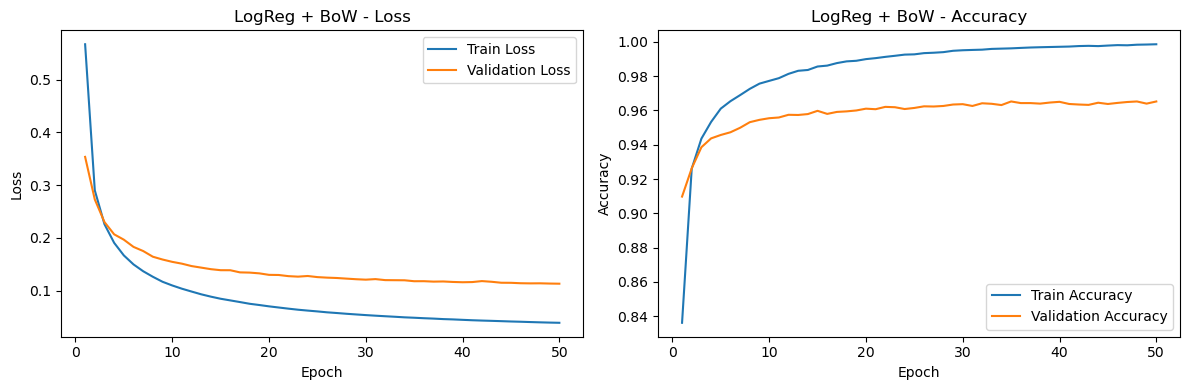

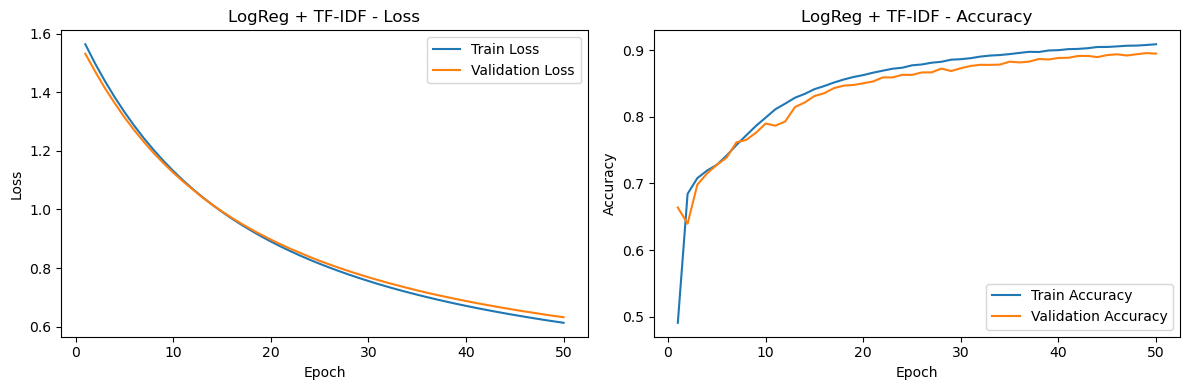

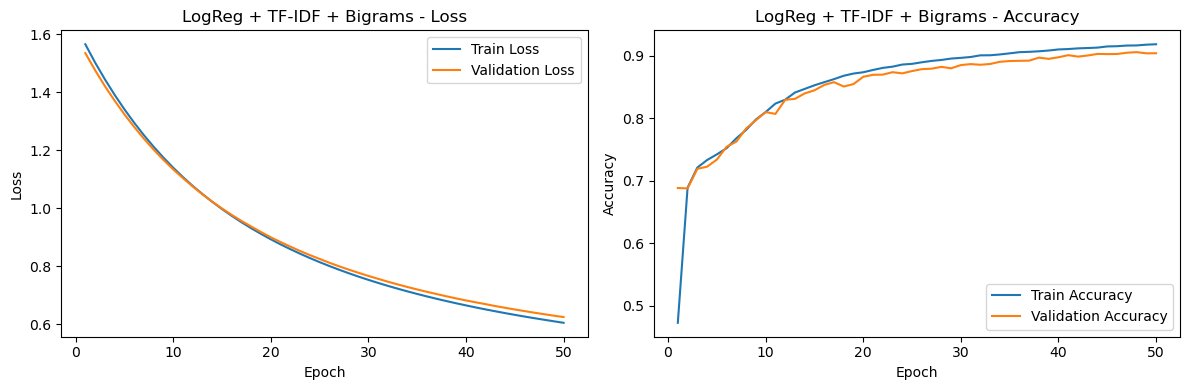

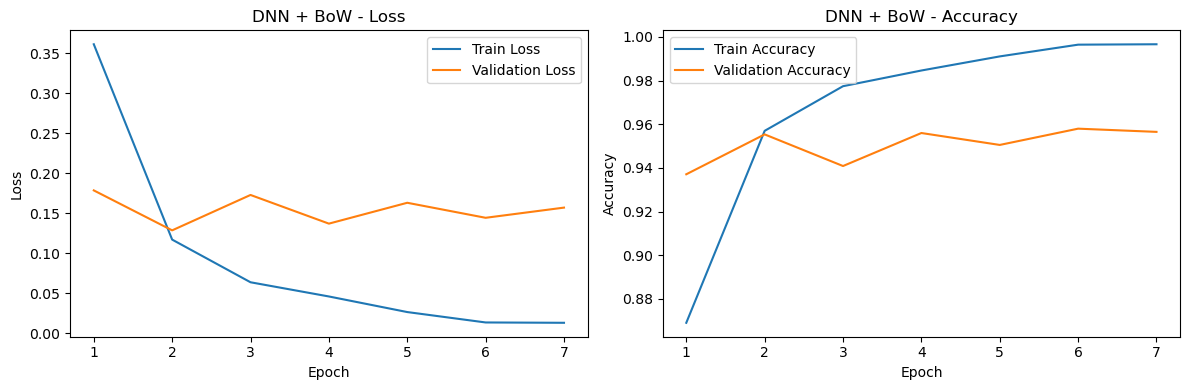

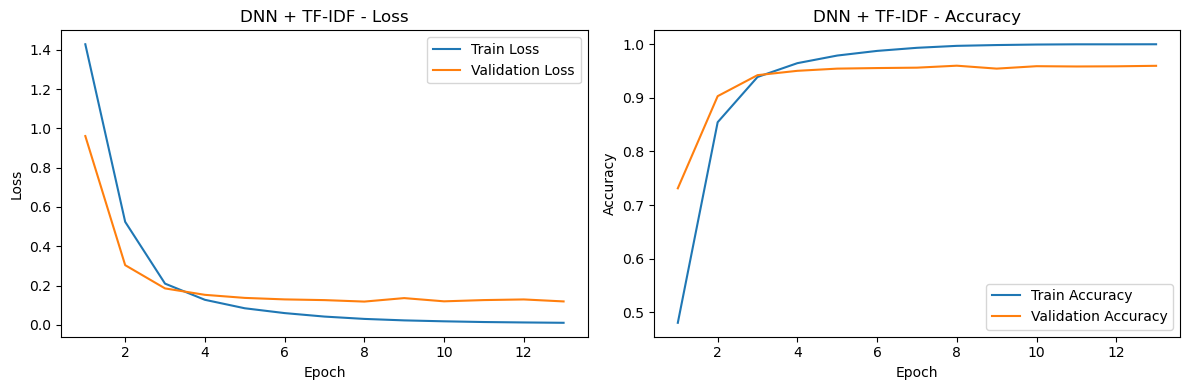

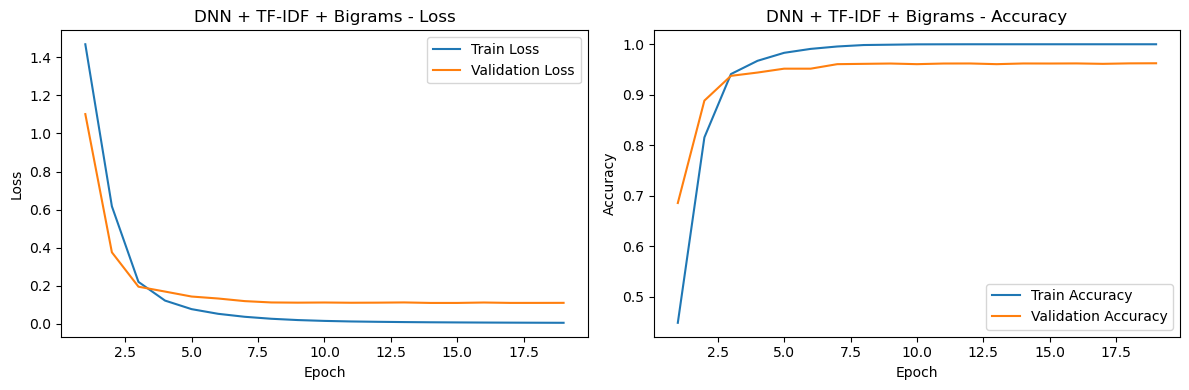

In [23]:
plot_history(results["logreg_bow"]["history"], title="LogReg + BoW")
plot_history(results["logreg_tfidf"]["history"], title="LogReg + TF-IDF")
plot_history(results["logreg_tfidf_bigram"]["history"], title="LogReg + TF-IDF + Bigrams")
plot_history(results["dnn_bow"]["history"], title="DNN + BoW")
plot_history(results["dnn_tfidf"]["history"], title="DNN + TF-IDF")
plot_history(results["dnn_tfidf_bigram"]["history"], title="DNN + TF-IDF + Bigrams")

## Escolher o melhor modelo

In [24]:
for name, result in results.items():
    print(name, "->", result["val_accuracy"])

best_model_name = max(results, key=lambda k: results[k]["val_accuracy"])
best_result = results[best_model_name]

best_model = best_result["model"]
best_vectorizer = best_result["vectorizer"]

print("Best model:", best_model_name)
print("Validation accuracy:", best_result["val_accuracy"])

logreg_bow -> 0.9652274398571279
dnn_tfidf -> 0.9599747872675701
dnn_tfidf_bigram -> 0.961970795251602
dnn_bow -> 0.9553524529887594
logreg_tfidf -> 0.8947368421052632
logreg_tfidf_bigram -> 0.9037714045593025
Best model: logreg_bow
Validation accuracy: 0.9652274398571279


In [25]:
def confusion_matrix_numpy(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
        
    return cm

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center",
                     color="black")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# TESTE COM SUMB1 COM LABELS

In [26]:
val_test_df = pd.read_csv("../subm1_labels_revealed.csv", sep=";")

display(val_test_df.head())

,ID,Text,Label
0,D2-1,A covalent bond is a chemical bond that involv...,Human
1,D2-2,A covalent bond forms when two atoms share one...,Anthropic
2,D2-3,A covalent bond is a type of chemical bond whe...,OpenAI
3,D2-4,A covalent bond is a chemical bond that involv...,Meta
4,D2-5,Driven by exciting developments in the field o...,Human


In [27]:
val_test_df["clean_text"] = val_test_df["Text"]
#val_test_df["clean_text"] = val_test_df["Text"].apply(clean_text)
texts_val_test = val_test_df["clean_text"].to_numpy()


In [28]:
test_results = {}
conf_matrices = {}

true_idx = np.array([label_to_idx[label] for label in val_test_df["Label"]])

for name, result in results.items():
    model = result["model"]
    vectorizer = result["vectorizer"]

    X_val_test = transform_texts(texts_val_test, vectorizer)
    val_test_data = Data(X_val_test, y=None)

    preds = model.predict(val_test_data)
    pred_idx = np.argmax(preds, axis=1)

    acc = np.mean(pred_idx == true_idx)

    cm = confusion_matrix_numpy(true_idx, pred_idx, num_classes)
    conf_matrices[name] = cm

    test_results[name] = acc
    print(f"{name}: {acc:.4f}")

logreg_bow: 0.6800
dnn_tfidf: 0.6700
dnn_tfidf_bigram: 0.6400
dnn_bow: 0.6500
logreg_tfidf: 0.6200
logreg_tfidf_bigram: 0.6500


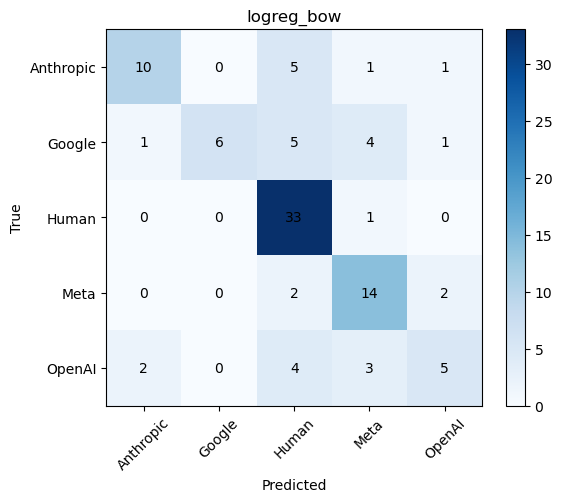

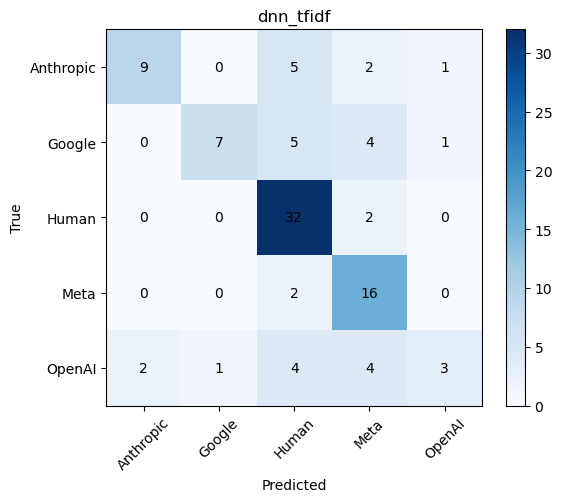

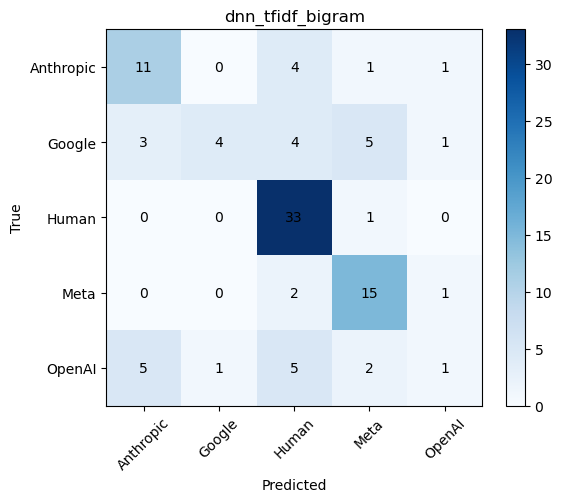

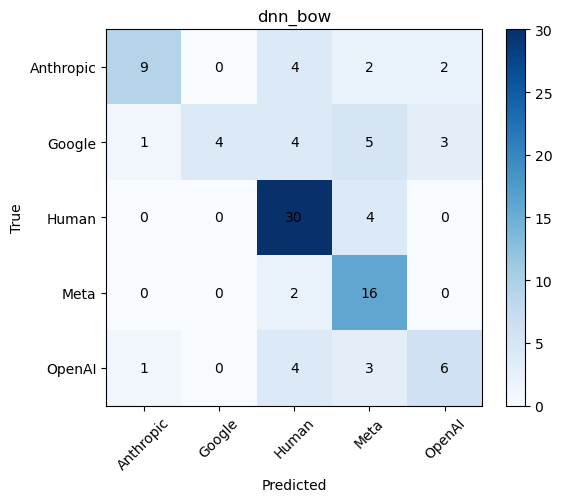

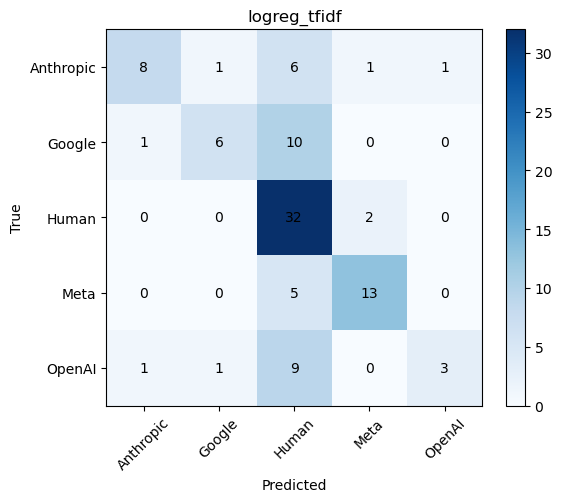

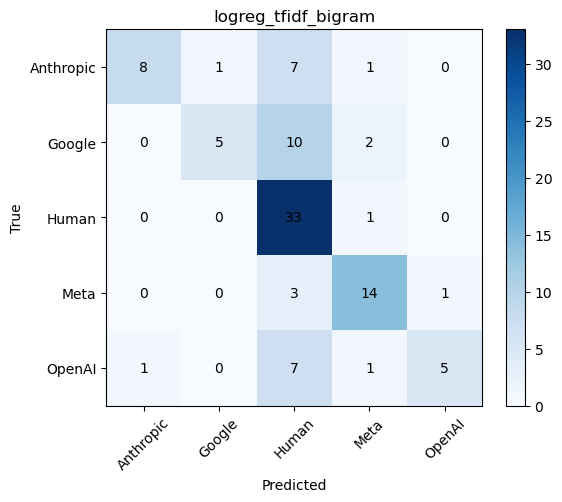

In [29]:
class_names = [k for k, v in sorted(label_to_idx.items(), key=lambda x: x[1])]

for name, cm in conf_matrices.items():
    plot_confusion_matrix(cm, class_names, title=name)

In [30]:
pred_labels = [idx_to_label[i] for i in pred_idx]
for i in range(10):
    print("Texto:", val_test_df["Text"].iloc[i][:80])
    print("Real:", val_test_df["Label"].iloc[i])
    print("Pred:", pred_labels[i])
    print("---")

Texto: A covalent bond is a chemical bond that involves the sharing of electrons to for
Real: Human
Pred: Human
---
Texto: A covalent bond forms when two atoms share one or more pairs of electrons, rathe
Real: Anthropic
Pred: Anthropic
---
Texto: A covalent bond is a type of chemical bond where two atoms share one or more pai
Real: OpenAI
Pred: Human
---
Texto: A covalent bond is a chemical bond that involves the sharing of electron pairs b
Real: Meta
Pred: Meta
---
Texto: Driven by exciting developments in the field of nanotechnology, which is one of 
Real: Human
Pred: Human
---
Texto: Ionic bonding results from the electrostatic attraction of oppositely charged io
Real: Human
Pred: Human
---
Texto: Plate tectonics is the scientific theory explaining how Earth's lithosphere—the 
Real: Anthropic
Pred: Anthropic
---
Texto: Plate tectonics is a fundamental scientific theory explaining the large-scale mo
Real: Google
Pred: Human
---
Texto: Tectonic plates are relatively rigid and float ac

# TESTE COM SUMB2 COM LABELS

In [31]:
val_test2_df = pd.read_csv("../subm2_labels_revealed.csv", sep=";")

display(val_test2_df.head())

,ID,Text,Label
0,D2-101,Microbial mats of coexisting bacteria and arch...,Human
1,D2-102,The origin of life on Earth remains a complex ...,OpenAI
2,D2-103,Estimates of the time at which life arose on E...,Human
3,D2-104,Life on Earth emerged roughly 3.8-4 billion ye...,Anthropic
4,D2-105,Black holes predominantly form from the catast...,Google


In [32]:
val_test2_df["clean_text"] = val_test2_df["Text"]
#val_test2_df["clean_text"] = val_test2_df["Text"].apply(clean_text)
texts_val_test2 = val_test2_df["clean_text"].to_numpy()


In [33]:
test2_results = {}
conf2_matrices = {}

true_idx = np.array([label_to_idx[label] for label in val_test2_df["Label"]])

for name, result in results.items():
    model = result["model"]
    vectorizer = result["vectorizer"]

    X_val_test2 = transform_texts(texts_val_test2, vectorizer)

    val_test2_data = Data(X_val_test2, y=None)

    preds = model.predict(val_test2_data)
    pred_idx = np.argmax(preds, axis=1)

    acc = np.mean(pred_idx == true_idx)

    cm = confusion_matrix_numpy(true_idx, pred_idx, num_classes)

    conf2_matrices[name] = cm
    test2_results[name] = acc
    print(f"{name}: {acc:.4f}")

logreg_bow: 0.5700
dnn_tfidf: 0.5800
dnn_tfidf_bigram: 0.6100
dnn_bow: 0.5700
logreg_tfidf: 0.5900
logreg_tfidf_bigram: 0.6000


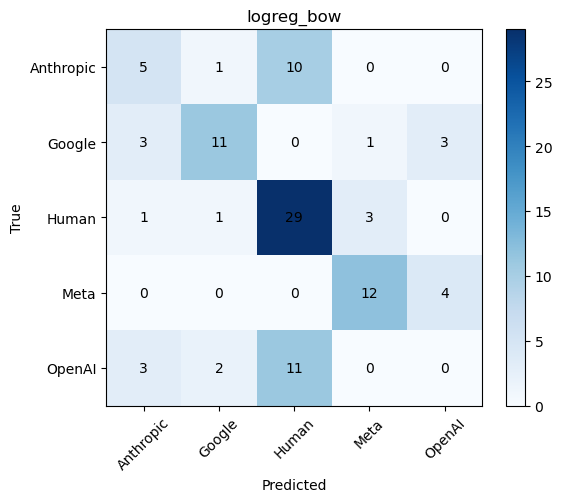

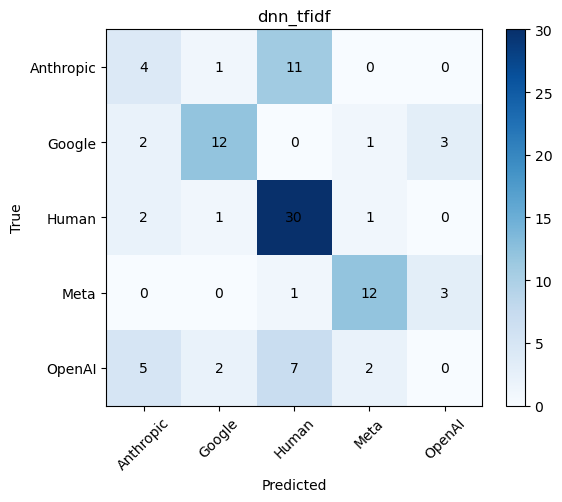

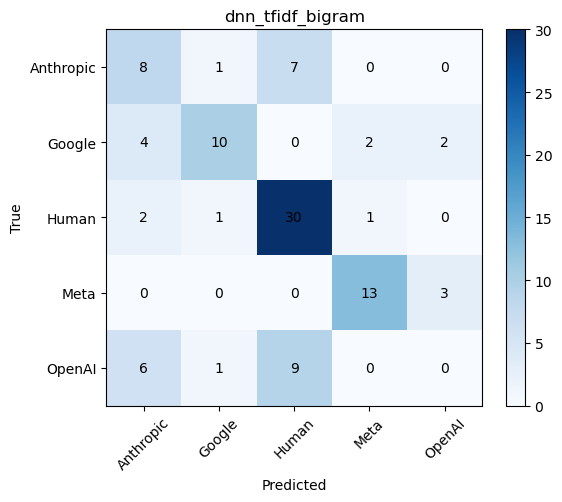

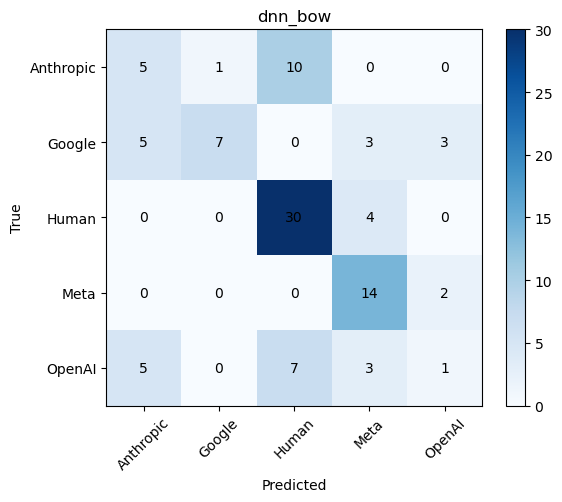

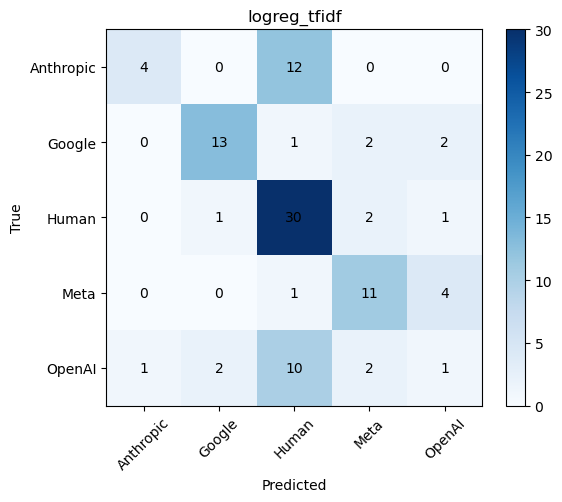

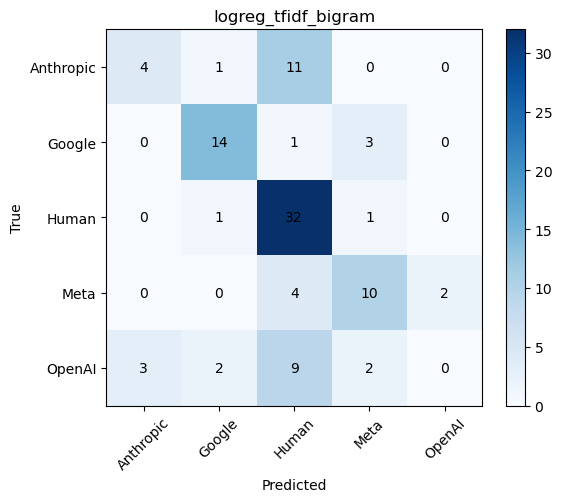

In [34]:
class_names = [k for k, v in sorted(label_to_idx.items(), key=lambda x: x[1])]

for name, cm in conf2_matrices.items():
    plot_confusion_matrix(cm, class_names, title=name)

In [35]:
pred_labels = [idx_to_label[i] for i in pred_idx]
for i in range(10):
    print("Texto:", val_test2_df["Text"].iloc[i][:80])
    print("Real:", val_test2_df["Label"].iloc[i])
    print("Pred:", pred_labels[i])
    print("---")

Texto: Microbial mats of coexisting bacteria and archaea were the dominant form of life
Real: Human
Pred: Human
---
Texto: The origin of life on Earth remains a complex and debated topic, but most scient
Real: OpenAI
Pred: Anthropic
---
Texto: Estimates of the time at which life arose on Earth make use of two types of evid
Real: Human
Pred: Human
---
Texto: Life on Earth emerged roughly 3.8-4 billion years ago through a process still no
Real: Anthropic
Pred: Anthropic
---
Texto: Black holes predominantly form from the catastrophic death of incredibly massive
Real: Google
Pred: Google
---
Texto: Black holes form primarily through the death of massive stars. When a star with 
Real: Anthropic
Pred: Anthropic
---
Texto: Black holes are formed when a massive star runs out of fuel and its core collaps
Real: Human
Pred: Meta
---
Texto: Black holes form when massive stars collapse under their own gravity at the end 
Real: OpenAI
Pred: Human
---
Texto: Supermassive black holes are extraordinari

# TESTE COM o Dataset de Teste

In [36]:
val_test3_df = pd.read_csv("../dataset_test_balanced.csv", sep=";")

display(val_test3_df.head())

,Original_ID,Text,Label
0,WIKI-7922,"Cory Doctorow's critique (""metacrap"") is from ...",Google
1,WIKI-3407,Devices that measure the electrical resistivit...,Google
2,WIKI-7050,"For simplicity, the following descriptions foc...",Google
3,WIKI-10919,Policy-based data sharing utilizes GPS-clock-s...,Meta
4,WIKI-1171,"In February 2013, researchers speculated that ...",Anthropic


In [37]:
val_test3_df["clean_text"] = val_test3_df["Text"]
#val_test3_df["clean_text"] = val_test3_df["Text"].apply(clean_text)
texts_val_test3 = val_test3_df["clean_text"].to_numpy()


In [38]:
test3_results = {}
conf3_matrices = {}

true_idx = np.array([label_to_idx[label] for label in val_test3_df["Label"]])

for name, result in results.items():
    model = result["model"]
    vectorizer = result["vectorizer"]

    X_val_test3 = transform_texts(texts_val_test3, vectorizer)

    val_test3_data = Data(X_val_test3, y=None)

    preds = model.predict(val_test3_data)
    pred_idx = np.argmax(preds, axis=1)

    acc = np.mean(pred_idx == true_idx)

    cm = confusion_matrix_numpy(true_idx, pred_idx, num_classes)

    conf3_matrices[name] = cm
    test3_results[name] = acc
    print(f"{name}: {acc:.4f}")

logreg_bow: 0.9676
dnn_tfidf: 0.9624
dnn_tfidf_bigram: 0.9696
dnn_bow: 0.9628
logreg_tfidf: 0.9004
logreg_tfidf_bigram: 0.9120


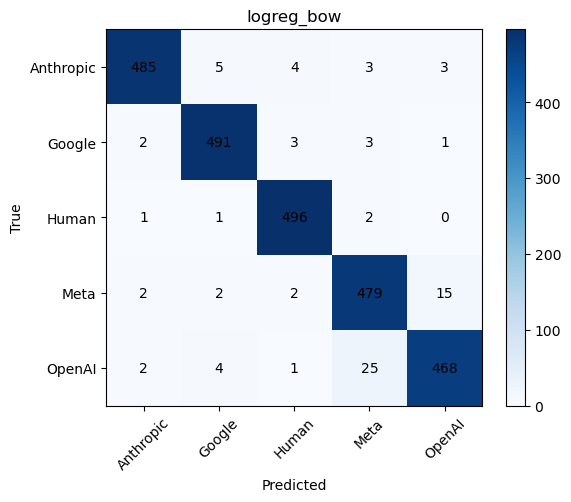

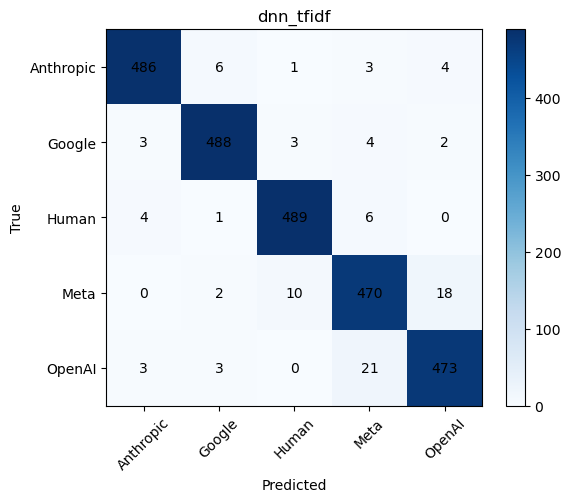

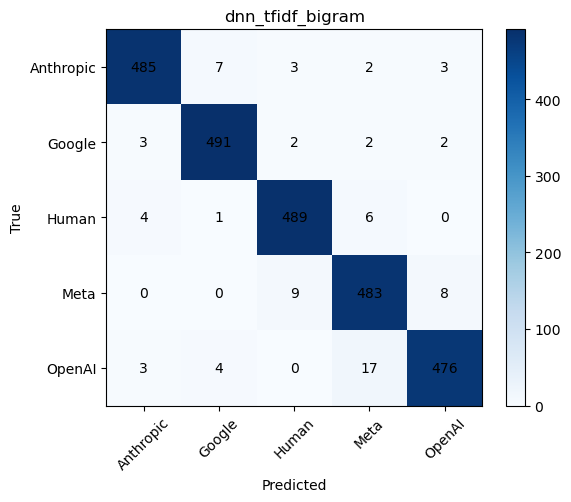

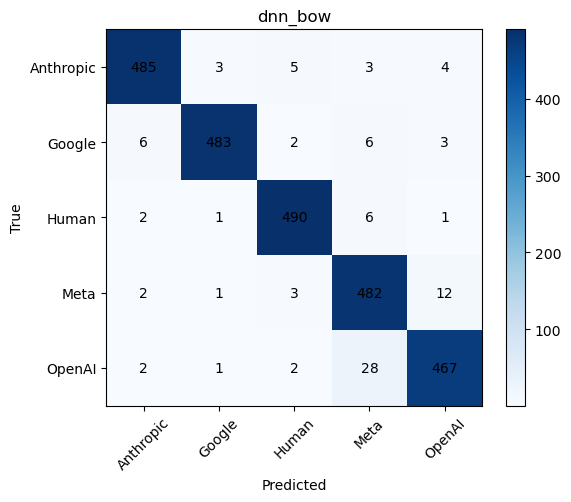

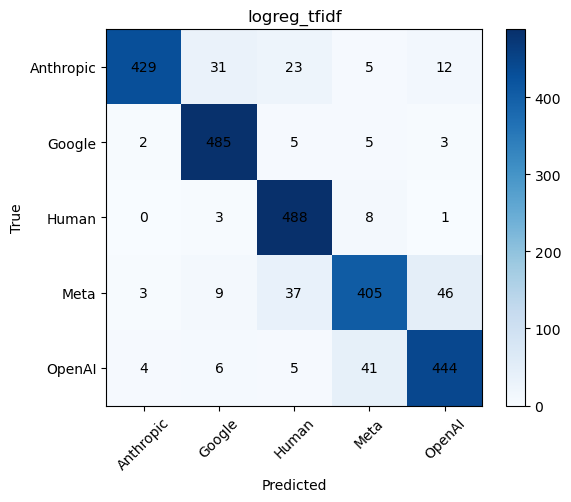

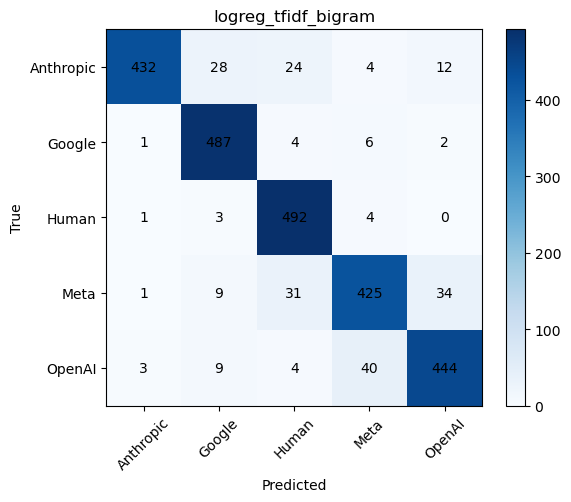

In [39]:
class_names = [k for k, v in sorted(label_to_idx.items(), key=lambda x: x[1])]

for name, cm in conf3_matrices.items():
    plot_confusion_matrix(cm, class_names, title=name)

In [40]:
pred_labels = [idx_to_label[i] for i in pred_idx]
for i in range(10):
    print("Texto:", val_test3_df["Text"].iloc[i][:80])
    print("Real:", val_test3_df["Label"].iloc[i])
    print("Pred:", pred_labels[i])
    print("---")

Texto: Cory Doctorow's critique ("metacrap") is from the perspective of human Cory Doct
Real: Google
Pred: Google
---
Texto: Devices that measure the electrical resistivity of the soil are Devices that mea
Real: Google
Pred: Google
---
Texto: For simplicity, the following descriptions focus on continuous-time and discrete
Real: Google
Pred: Google
---
Texto: Policy-based data sharing utilizes GPS-clock-synchronized-fine-grain power grid 
Real: Meta
Pred: OpenAI
---
Texto: In February 2013, researchers speculated that up to 6% of the global population 
Real: Anthropic
Pred: Anthropic
---
Texto: The first electronic excited state of an alkene lacks the necessary stability to
Real: OpenAI
Pred: OpenAI
---
Texto: Thus, complicated experimental designs are sometimes necessary to account for th
Real: Anthropic
Pred: Anthropic
---
Texto: A heavy nucleus can contain hundreds of nucleons. This means That a large nucleu
Real: Meta
Pred: Meta
---
Texto: Water passes through a heat exchanger in a 

# TESTE COM o Dataset de TesteV3

In [41]:
val_test4_df = pd.read_csv("../dataset_final_v3.csv", sep=";")

display(val_test4_df.head())

,ID,Text,Label
0,D1-0001,Microbial genetics explores how genes control ...,OpenAI
1,D1-0002,"White dwarfs are the dense, hot stellar cores ...",Meta
2,D1-0003,Diodes are two-terminal semiconductor devices ...,Anthropic
3,D1-0004,"Decoy State Quantum Key Distribution (QKD), be...",Human
4,D1-0005,Wireless power transfer is an emerging field i...,OpenAI


In [42]:
val_test4_df["clean_text"] = val_test4_df["Text"]
#val_test4_df["clean_text"] = val_test4_df["Text"].apply(clean_text)
texts_val_test4 = val_test4_df["clean_text"].to_numpy()

In [43]:
test4_results = {}
conf4_matrices = {}

true_idx = np.array([label_to_idx[label] for label in val_test4_df["Label"]])

for name, result in results.items():
    model = result["model"]
    vectorizer = result["vectorizer"]

    X_val_test4 = transform_texts(texts_val_test4, vectorizer)

    val_test4_data = Data(X_val_test4, y=None)

    preds = model.predict(val_test4_data)
    pred_idx = np.argmax(preds, axis=1)

    acc = np.mean(pred_idx == true_idx)

    cm = confusion_matrix_numpy(true_idx, pred_idx, num_classes)

    conf4_matrices[name] = cm
    test4_results[name] = acc
    print(f"{name}: {acc:.4f}")

logreg_bow: 0.2333
dnn_tfidf: 0.2664
dnn_tfidf_bigram: 0.2600
dnn_bow: 0.2469
logreg_tfidf: 0.2045
logreg_tfidf_bigram: 0.2136


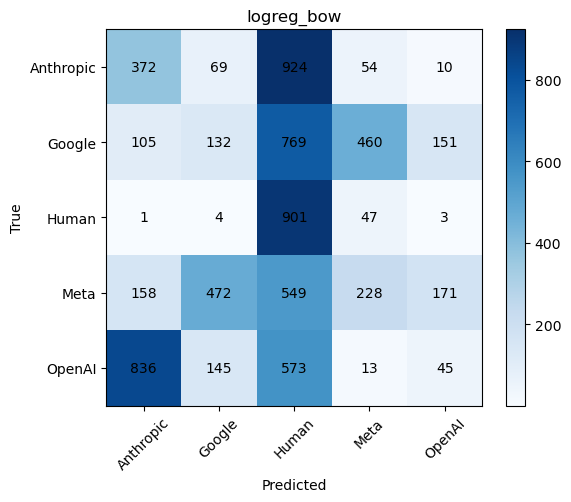

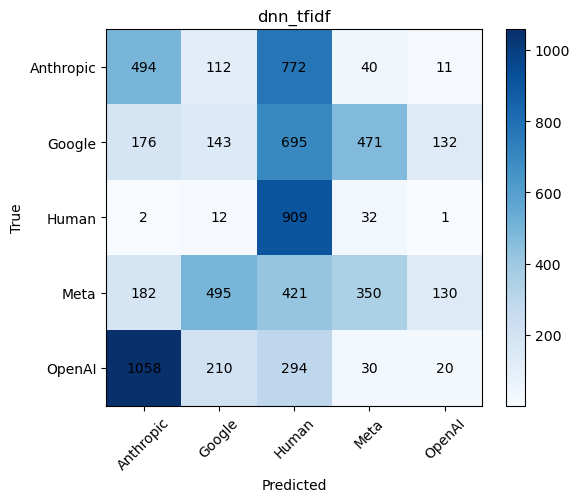

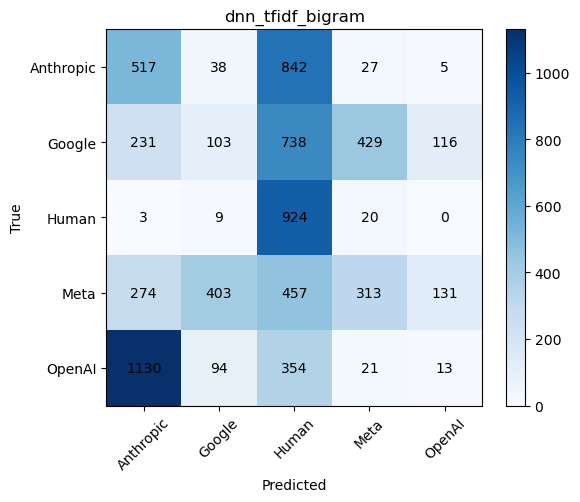

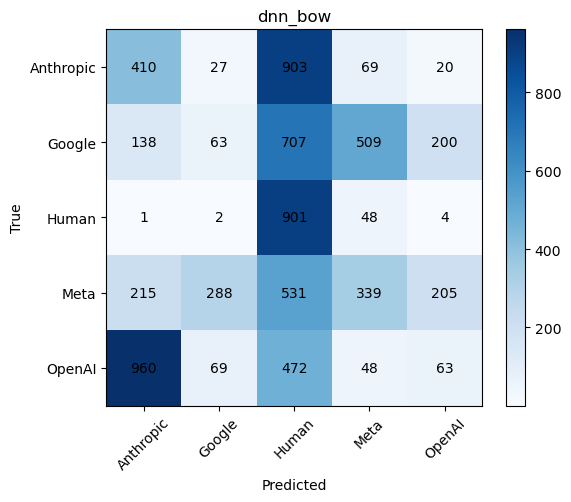

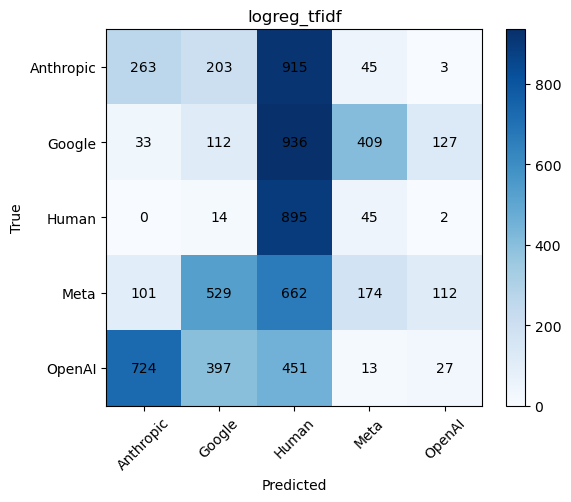

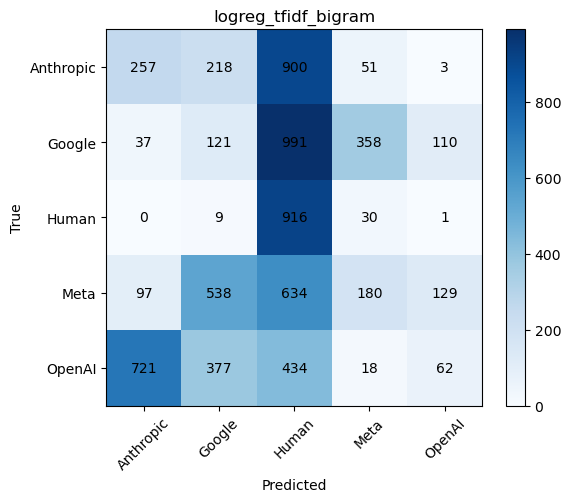

In [44]:
class_names = [k for k, v in sorted(label_to_idx.items(), key=lambda x: x[1])]

for name, cm in conf4_matrices.items():
    plot_confusion_matrix(cm, class_names, title=name)

In [45]:
pred_labels = [idx_to_label[i] for i in pred_idx]
for i in range(10):
    print("Texto:", val_test4_df["Text"].iloc[i][:80])
    print("Real:", val_test4_df["Label"].iloc[i])
    print("Pred:", pred_labels[i])
    print("---")

Texto: Microbial genetics explores how genes control cellular processes and how genetic
Real: OpenAI
Pred: Anthropic
---
Texto: White dwarfs are the dense, hot stellar cores left behind after low-to-medium ma
Real: Meta
Pred: Human
---
Texto: Diodes are two-terminal semiconductor devices that allow current to flow predomi
Real: Anthropic
Pred: Human
---
Texto: Decoy State Quantum Key Distribution (QKD), being capable of beating PNS attack 
Real: Human
Pred: Human
---
Texto: Wireless power transfer is an emerging field in electrical engineering, enabling
Real: OpenAI
Pred: Google
---
Texto: Calculus plays a pivotal role in physics, forming the mathematical language for 
Real: Meta
Pred: Google
---
Texto: The chain rule is a crucial technique in differential calculus used for finding 
Real: Google
Pred: Human
---
Texto: Kin selection is an evolutionary mechanism through which alleles that promote al
Real: Anthropic
Pred: Human
---
Texto: Phylogenetics is the scientific discipline concern

# Predict Submision

In [60]:
model_name = "dnn_tfidf_bigram"   # escolhe aqui
#model_name = max(results, key=lambda k: results[k]["val_accuracy"])

In [61]:
selected_result = results[model_name]

model = selected_result["model"]
vectorizer = selected_result["vectorizer"]

print("Using model:", model_name)

Using model: dnn_tfidf_bigram


In [62]:
X_test = transform_texts(test_df["clean_text"].to_numpy(), vectorizer)

In [63]:
test_data = Data(X_test, y=None)

In [64]:
pred_probs = model.predict(test_data)
pred_idx = np.argmax(pred_probs, axis=1)

In [65]:
pred_labels = [idx_to_label[i] for i in pred_idx]

In [66]:
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "Label": pred_labels
})

submission.to_csv("subm3-g6-MEI-A.csv", sep=";", index=False)
display(submission.head())

,ID,Label
0,D2-126,Human
1,D2-127,Human
2,D2-128,Human
3,D2-129,Human
4,D2-130,Google
